<a href="https://colab.research.google.com/github/dikshabachchani/powerbidashboards/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
data = pd.read_csv("/content/archive (2).zip")

print("Dataset Loaded Successfully")
print(data.head())

Dataset Loaded Successfully
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [3]:
print("\nShape of Dataset:")
print(data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nInformation:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())



Shape of Dataset:
(301, 9)

Column Names:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type       

In [4]:
data["Car_Age"] = 2025 - data["Year"]

# Drop unnecessary columns
data.drop(["Year", "Car_Name"], axis=1, inplace=True)

print("\nDataset after Feature Engineering")
print(data.head())


Dataset after Feature Engineering
   Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type  \
0           3.35           5.59       27000    Petrol       Dealer   
1           4.75           9.54       43000    Diesel       Dealer   
2           7.25           9.85        6900    Petrol       Dealer   
3           2.85           4.15        5200    Petrol       Dealer   
4           4.60           6.87       42450    Diesel       Dealer   

  Transmission  Owner  Car_Age  
0       Manual      0       11  
1       Manual      0       12  
2       Manual      0        8  
3       Manual      0       14  
4       Manual      0       11  


In [5]:
encoder = LabelEncoder()

data["Fuel_Type"] = encoder.fit_transform(data["Fuel_Type"])
data["Selling_type"] = encoder.fit_transform(data["Selling_type"])
data["Transmission"] = encoder.fit_transform(data["Transmission"])

print("\nDataset after Encoding")
print(data.head())


Dataset after Encoding
   Selling_Price  Present_Price  Driven_kms  Fuel_Type  Selling_type  \
0           3.35           5.59       27000          2             0   
1           4.75           9.54       43000          1             0   
2           7.25           9.85        6900          2             0   
3           2.85           4.15        5200          2             0   
4           4.60           6.87       42450          1             0   

   Transmission  Owner  Car_Age  
0             1      0       11  
1             1      0       12  
2             1      0        8  
3             1      0       14  
4             1      0       11  


In [6]:
X = data.drop("Selling_Price", axis=1)

y = data["Selling_Price"]

print("\nInput Features")
print(X.head())

print("\nTarget")
print(y.head())


Input Features
   Present_Price  Driven_kms  Fuel_Type  Selling_type  Transmission  Owner  \
0           5.59       27000          2             0             1      0   
1           9.54       43000          1             0             1      0   
2           9.85        6900          2             0             1      0   
3           4.15        5200          2             0             1      0   
4           6.87       42450          1             0             1      0   

   Car_Age  
0       11  
1       12  
2        8  
3       14  
4       11  

Target
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (240, 7)
Testing Data: (61, 7)


In [8]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [9]:
predictions = model.predict(X_test)

print("\nPredicted Prices")
print(predictions[:10])



Predicted Prices
[ 0.444  10.8836  4.9115  0.2194  7.821   6.227   1.098   0.5899  0.4704
  6.8995]


In [10]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("\nModel Performance")

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)



Model Performance
Mean Absolute Error : 0.6389196721311476
Mean Squared Error : 0.9382767457377043
Root Mean Squared Error : 0.9686468632776881
R2 Score : 0.9592683769360726


In [11]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

print("\nComparison")
print(comparison.head(15))


Comparison
    Actual Price  Predicted Price
0           0.35           0.4440
1          10.11          10.8836
2           4.95           4.9115
3           0.15           0.2194
4           6.95           7.8210
5           7.45           6.2270
6           1.10           1.0980
7           0.50           0.5899
8           0.45           0.4704
9           6.00           6.8995
10          9.25           7.9723
11          1.10           1.1065
12          7.50           8.2073
13          0.40           0.4542
14          6.15           5.3080


In [12]:
importance = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance_df)


Feature Importance
         Feature  Importance
0  Present_Price    0.884504
6        Car_Age    0.060462
1     Driven_kms    0.034973
4   Transmission    0.009999
2      Fuel_Type    0.006507
3   Selling_type    0.003489
5          Owner    0.000067


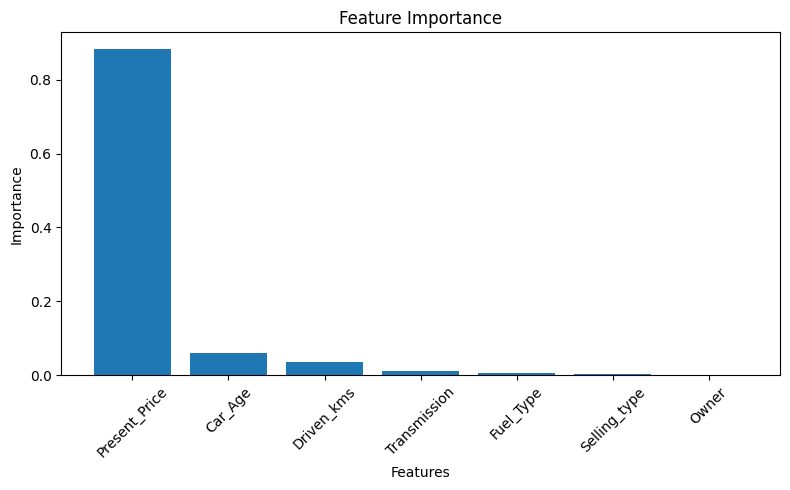

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


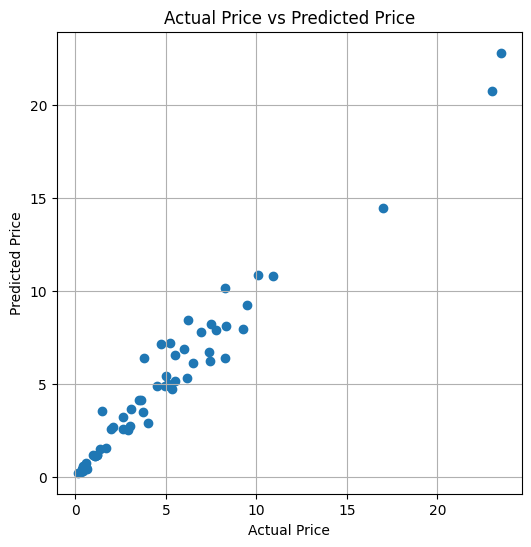

In [14]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual Price vs Predicted Price")

plt.grid(True)

plt.show()

In [15]:
sample_car = [[5.59, 27000, 1, 0, 1, 0, 11]]

predicted_price = model.predict(sample_car)

print("\nPredicted Price of New Car:")

print(predicted_price[0], "Lakhs")


Predicted Price of New Car:
3.835500000000004 Lakhs


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
